# **Part A-Data Loading and Preprocessing with Scikit-learn**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## Task 1-Load and Understand the Dataset

In [9]:
df=pd.read_csv("hotel_bookings.csv")
print(df.head())
print("Shape:", df.shape)
df.info()
print(df.describe())
print(df.dtypes)
print("\nClass Distribution:")
print(df["is_canceled"].value_counts())
y=df["is_canceled"]
X=df.drop("is_canceled", axis=1)
numerical_cols=X.select_dtypes(include="number").columns.tolist()
categorical_cols=X.select_dtypes(include="object").columns.tolist()
print("\nNumerical Columns:")
print(numerical_cols)
print("\nCategorical Columns:")
print(categorical_cols)

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

## Task 2-Missing Values, Leakage, and Outliers

In [10]:
missing_count=df.isnull().sum()
missing_percent=(missing_count / len(df))*100
missing=pd.DataFrame({"Missing Count":missing_count,"Missing Percentage":missing_percent})
print("\nMissing Values:")
print(missing)
print("\nColumns with very high missingness:")
print(missing[missing["Missing Percentage"] > 50])
df=df.drop("company", axis=1)
df=df.drop(["reservation_status", "reservation_status_date"], axis=1)
print("\nDropped 'company' because it has very high missingness.")
print("Dropped 'reservation_status' and 'reservation_status_date' because they cause data leakage.")


Missing Values:
                                Missing Count  Missing Percentage
hotel                                       0            0.000000
is_canceled                                 0            0.000000
lead_time                                   0            0.000000
arrival_date_year                           0            0.000000
arrival_date_month                          0            0.000000
arrival_date_week_number                    0            0.000000
arrival_date_day_of_month                   0            0.000000
stays_in_weekend_nights                     0            0.000000
stays_in_week_nights                        0            0.000000
adults                                      0            0.000000
children                                    4            0.003350
babies                                      0            0.000000
meal                                        0            0.000000
country                                   488            0.

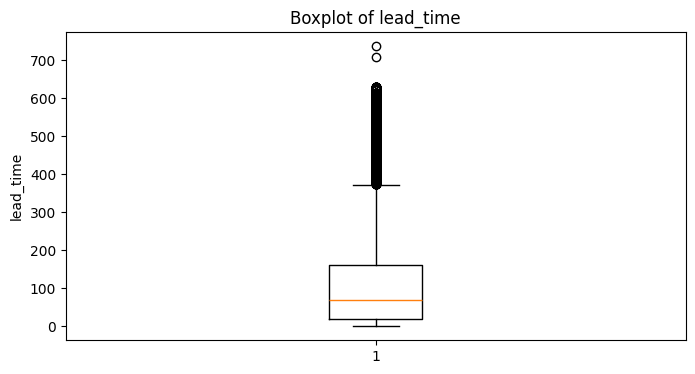

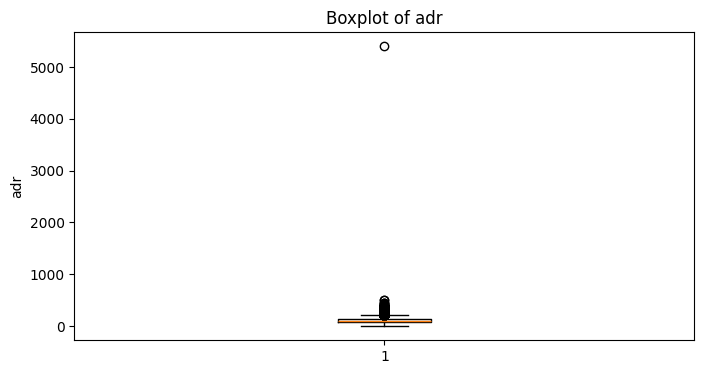

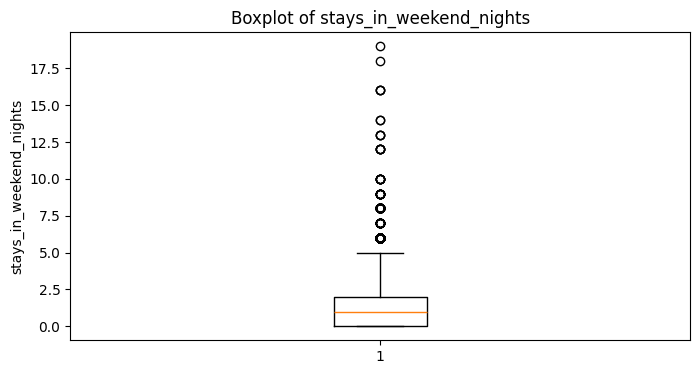

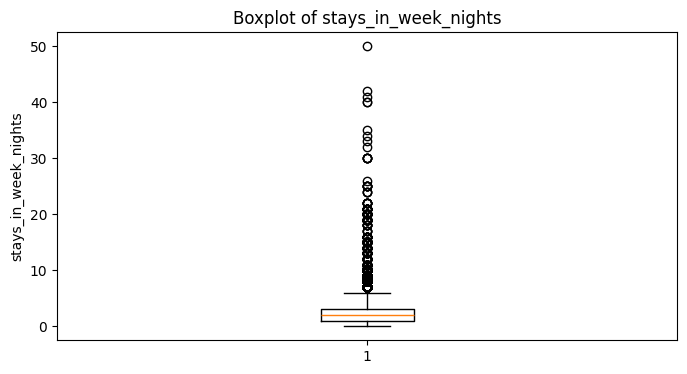

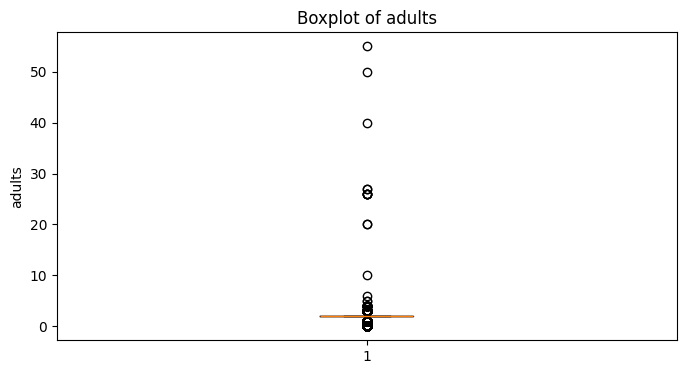

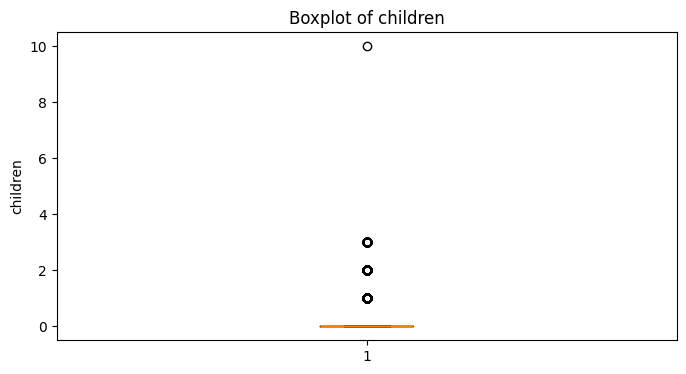

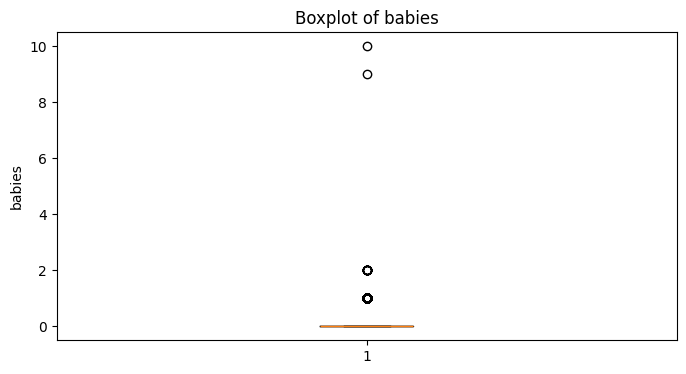

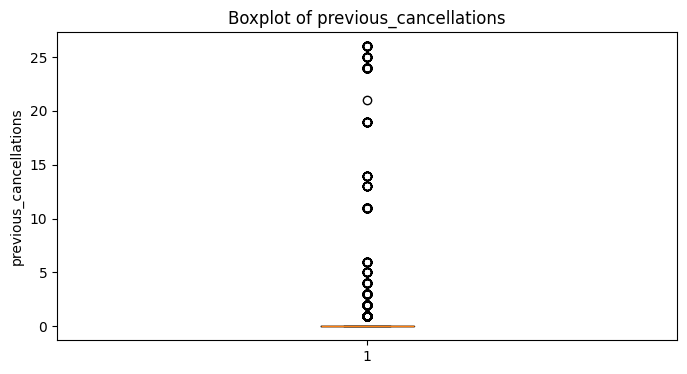

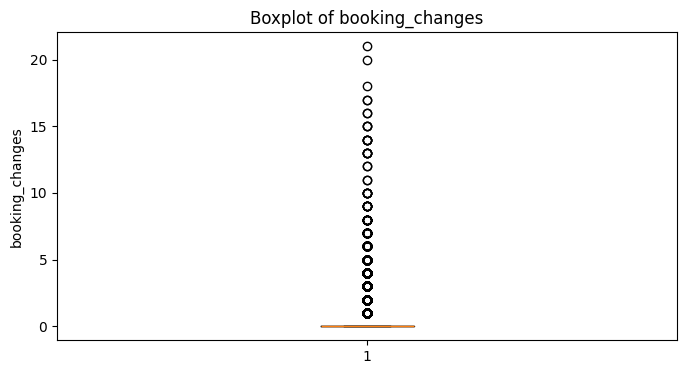

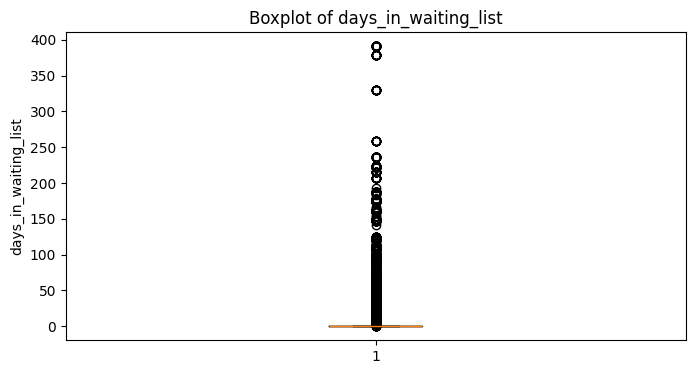

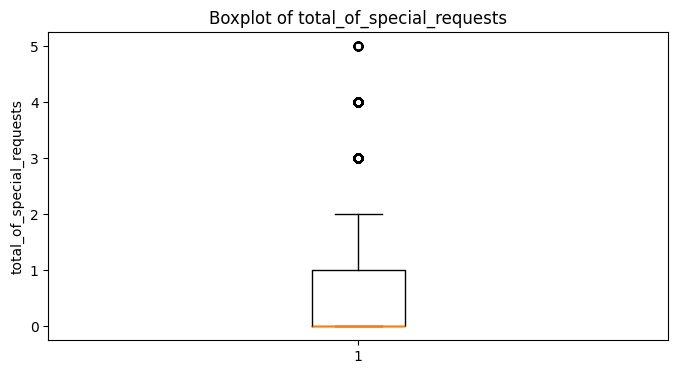


Rows removed due to extreme outliers: 3793
Rows remaining: 115597


In [11]:
selected_numeric=["lead_time","adr","stays_in_weekend_nights","stays_in_week_nights","adults","children","babies","previous_cancellations","booking_changes",
"days_in_waiting_list","total_of_special_requests" ]
for col in selected_numeric:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

Q1=df["adr"].quantile(0.25)
Q3=df["adr"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
before=len(df)
df=df[(df["adr"]>= lower) & (df["adr"]<= upper)]
after=len(df)
print("\nRows removed due to extreme outliers:", before-after)
print("Rows remaining:", after)

## Task 3-Create Two Preprocessing Pipelines

In [12]:
X=df.drop("is_canceled", axis=1)
y=df["is_canceled"]
numerical_cols=X.select_dtypes(include="number").columns.tolist()
categorical_cols=X.select_dtypes(include="object").columns.tolist()
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

categorical_pipeline=Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])

pipeline_A=ColumnTransformer([("num", Pipeline([("imputer", KNNImputer(n_neighbors=5)),("scaler", StandardScaler())]), numerical_cols),
("cat", categorical_pipeline, categorical_cols)])

pipeline_B=ColumnTransformer([("num", Pipeline([("imputer", KNNImputer(n_neighbors=5)),("scaler", MinMaxScaler())]), numerical_cols),
("cat", categorical_pipeline, categorical_cols)])

# **Part B-Model Training and Performance Evaluation**

## Task 4-Train Two Classification Models

In [13]:
lr_A=Pipeline([("preprocessing", pipeline_A),("model", LogisticRegression(max_iter=1000))])
lr_B=Pipeline([("preprocessing", pipeline_B),("model", LogisticRegression(max_iter=1000))])

dt_A=Pipeline([("preprocessing", pipeline_A),("model", DecisionTreeClassifier(random_state=42))])
dt_B=Pipeline([("preprocessing", pipeline_B),("model", DecisionTreeClassifier(random_state=42))])

lr_A.fit(X_train, y_train)
lr_B.fit(X_train, y_train)
dt_A.fit(X_train, y_train)
dt_B.fit(X_train, y_train)

print("\nAll four models trained successfully.")


All four models trained successfully.


## Task 5-Evaluate and Compare the Four Results

In [14]:
models={"Logistic Regression-StandardScaler":lr_A,"Logistic Regression-MinMaxScaler":lr_B,"Decision Tree-StandardScaler":dt_A,"Decision Tree-MinMaxScaler":dt_B}
results=[]
for name, model in models.items():
    train_pred=model.predict(X_train)
    test_pred=model.predict(X_test)
    train_accuracy=accuracy_score(y_train, train_pred)
    test_accuracy=accuracy_score(y_test, test_pred)
    precision=precision_score(y_test, test_pred)
    recall=recall_score(y_test, test_pred)
    f1=f1_score(y_test, test_pred)
    results.append([name,train_accuracy,test_accuracy,precision,recall,f1])
results_df=pd.DataFrame(results, columns=["Model","Training Accuracy","Testing Accuracy","Precision","Recall","F1-Score"])
print("\nFinal Comparison Table:")
print(results_df.round(4))


Final Comparison Table:
                                Model  Training Accuracy  Testing Accuracy  \
0  Logistic Regression-StandardScaler             0.8213            0.8164   
1    Logistic Regression-MinMaxScaler             0.8168            0.8126   
2        Decision Tree-StandardScaler             0.9960            0.8663   
3          Decision Tree-MinMaxScaler             0.9960            0.8665   

   Precision  Recall  F1-Score  
0     0.8085  0.6599    0.7267  
1     0.8055  0.6505    0.7197  
2     0.8148  0.8263    0.8205  
3     0.8151  0.8266    0.8208  


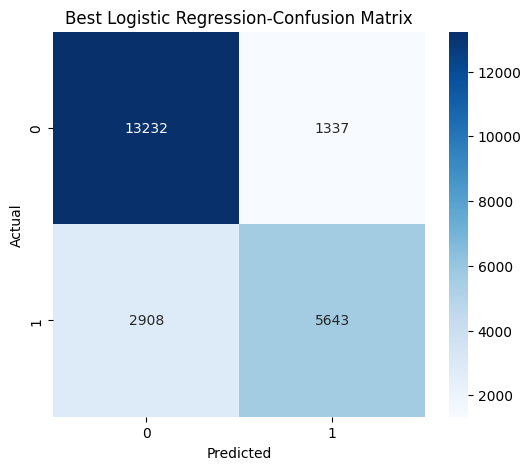

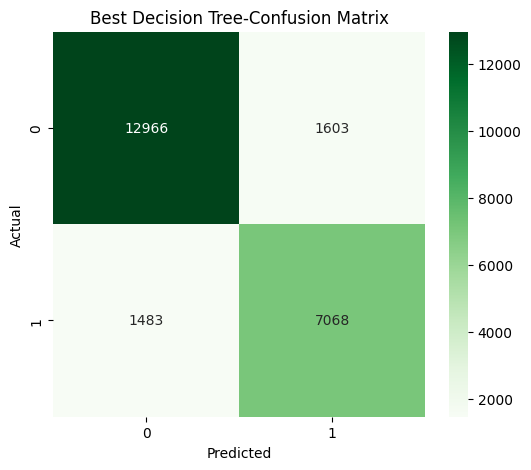


Train-Test Performance Difference:
                                Model  Train-Test Difference
0  Logistic Regression-StandardScaler                 0.0049
1    Logistic Regression-MinMaxScaler                 0.0042
2        Decision Tree-StandardScaler                 0.1297
3          Decision Tree-MinMaxScaler                 0.1295


In [15]:
lr_results=results_df[results_df["Model"].str.contains("Logistic Regression")]
best_lr_name=lr_results.loc[lr_results["F1-Score"].idxmax(), "Model"]
best_lr_model=models[best_lr_name]
lr_test_pred=best_lr_model.predict(X_test)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, lr_test_pred),annot=True,fmt="d",cmap="Blues")
plt.title("Best Logistic Regression-Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

dt_results=results_df[results_df["Model"].str.contains("Decision Tree")]
best_dt_name=dt_results.loc[dt_results["F1-Score"].idxmax(), "Model"]
best_dt_model=models[best_dt_name]
dt_test_pred=best_dt_model.predict(X_test)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, dt_test_pred),annot=True,fmt="d",cmap="Greens")
plt.title("Best Decision Tree-Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

results_df["Train-Test Difference"]=(results_df["Training Accuracy"]-results_df["Testing Accuracy"])
print("\nTrain-Test Performance Difference:")
print(results_df[["Model", "Train-Test Difference"]].round(4))

## Task 6 - Final Observations

**Observations:**

1.   The model with the highest F1-score and testing accuracy is considered the best preprocessing-model combination.
2.   StandardScaler and MinMaxScaler can affect Logistic Regression because it is sensitive to feature scaling. The better scaler is determined by comparing their test F1-scores.
3. Scaling does not make a major difference to Decision Tree performance because trees are based on feature split points rather than feature magnitude.
4. The confusion matrices show that the best models correctly classified most bookings, with fewer false predictions compared with incorrect classifications.
5. The difference between training and testing accuracy indicates some overfitting, particularly for the Decision Tree, while Logistic Regression showed better generalization.

